[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss shape optimization

Last updated: 06/27/26

## Description

Optimize the shape of a truss structure to achieve its 
minimum weight. 

The bars are grouped into four groups: bottom chord, top chord,
verticals, and diagonals. The bars are manufactured out of square hollow tubes.

Objective function: mass of the structure. The design variables are the 
shifts of the joints of the upper chord from their reference positions.

Constraints: (1) limit on maximum deflection, and (2) the bars must remain elastic,
(3) the bars in compression must not buckle, and (4) the design variables 
are bounded both from below and from above, so that the joints don't move too far
from their reference position.

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraints
$$
    c_j(x) \ge 0 \; , j=1,4
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)



As usual, we bring in the modules and functions that we will need.

In [1]:
import scipy
import context
from math import pi
from numpy import max, ones, zeros, inf, minimum
from pystran import model
from pystran import section
from pystran import truss
from pystran import geometry
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. First, we define some useful constants.


Maximum allowed deflection (in millimeters)


In [2]:
MAXIMUM_ALLOWED_DEFLECTION = 10.0

For convenience, we define the length `L`. The locations are the joints can be varied by adding a fraction of the `SHIFT`.

In [3]:
SHIFT = 1400
L = 3000


The material properties correspond roughly to steel.


In [4]:
E = 200000
RHO = 8.0e-9
sigy = E / 1000


The magnitude of the vertical (downward) forces in Newton.


In [5]:
W = 6000

First we define the groups of bars. Note that with respect to the previous tutorials, two diagonals have been flipped so that there are no null bars in the structure "as designed".

In [6]:
group_names = ["bottom_chord", "top_chord", "verticals", "diagonals"]
NGROUPS = len(group_names)
group_bars = [
    [ # bottom_chord
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ],
    [ # top_chord
        [6, 7],
        [7, 8],
        [8, 9],
        [9, 10],
    ],
    [ # verticals
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
        [5, 10],
    ],
    [ # diagonals
        [2, 6],
        [3, 9],
        [3, 7],
        [4, 10],
    ]
    ]

The cross sectional properties for each group are fixed.


In [7]:
group_inner_dim = [15.0, 40.0, 40.0, 40.0]
group_thickness = [1.5, 2.0, 2.0, 2.0]


The functions to calculate the area of a bar and its moment of area are defined.

In [8]:
def _area(d, t):
    return (d + 2*t)**2 - d**2 

def _second_moment(d, t):
    return ((d + 2*t)**4 - d**4) / 12

There are 5 joints in the upper chord, and each can be moved horizontally or vertically. Therefore there are 10 design variables, such that the location of a joint in the upper chord is its original location plus one design variable times the shift in  the horizontal direction and another design variable times the shift in the vertical direction. The "as designed" structure has the joints in the original locations, and so the design variables start at zero.

In [9]:
dvs0 = zeros(10)

This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`. Note the use of the design variables to shift the joints.


In [10]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-2*L + dvs[0] * SHIFT, 0 + dvs[1] * SHIFT])
    model.add_joint(m, 7, [-L + dvs[2] * SHIFT, 0 + dvs[3] * SHIFT])
    model.add_joint(m, 8, [0 + dvs[4] * SHIFT, 0 + dvs[5] * SHIFT])
    model.add_joint(m, 9, [L + dvs[6] * SHIFT, 0 + dvs[7] * SHIFT])
    model.add_joint(m, 10, [2*L + dvs[8] * SHIFT, 0 + dvs[9] * SHIFT])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    for g in range(NGROUPS):
        s = section.truss_section(g, E=E, A=_area(group_inner_dim[g], group_thickness[g]), rho=RHO)
        s['I'] = _second_moment(group_inner_dim[g], group_thickness[g])
        for k, c in enumerate(group_bars[g]):
            model.add_truss_member(m, f"{group_names[g]}_{k}", c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


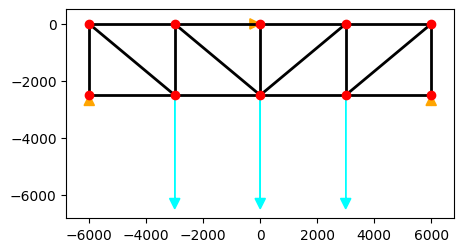

In [11]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The following calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [12]:
mass = RHO * model.volume(m)
print('Initial mass = ', 1000 * mass, ' [kg]')

Initial mass =  117.34790225767416  [kg]


The `solve` helper function is defined to compute the design 
responses (`drs`). Static response of the structure is computed. 

For each member we compute an array of buckling and yielding constraints.
The buckling constraint is that the force in the bar, $F$, must be at most equal to $-F_{Euler}=-\pi^2 EI/h^2$:
$$
F \ge -F_{Euler}
$$
This may be converted to a nondimensional form
$$
F /F_{Euler}+1  \ge 0
$$
The yielding constraint may be written in terms of the axial stress
$$
|\sigma|\le \sigma_y
$$
This can be rewritten in nondimensional form
$$
1-|\sigma|/\sigma_y\ge 0
$$
All constraint design responses are already in the form of  nondimensionalized constraints.

In [13]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    buckling = zeros(NGROUPS) + inf
    yielding = zeros(NGROUPS) + inf
    for member in m["truss_members"].values():
        c = member["connectivity"]
        i, j = m["joints"][c[0]], m["joints"][c[1]]
        sect = member["section"]
        A = sect['A']
        I = sect['I']
        _, _, h = geometry.member_2d_geometry(i, j)
        F_eul = pi**2 * E * I / h**2
        F = truss.truss_axial_force(member, i, j, 0.0)
        g = sect['name']
        buckling[g] = minimum(buckling[g], F / F_eul + 1)
        sig = F / A
        yielding[g] = minimum(yielding[g], 1 - abs(sig / sigy))
    drs = (
        RHO * model.volume(m),
        (MAXIMUM_ALLOWED_DEFLECTION - max(abs(m["U"]))) / MAXIMUM_ALLOWED_DEFLECTION,
        buckling,
        yielding
    )
    return drs

Now we can report on the performance of the structure 
as originally designed.


In [14]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_max_deflection = drs[1]
initial_buckling = drs[2]
initial_yielding = drs[3]
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", 1000 * initial_mass, ' [kg]')
print("Initial largest deflection: ", initial_max_deflection)
print("Initial buckling: ", initial_buckling)
print("Initial yielding: ", initial_yielding)



Initial structure
-----------------
Initial Design Variables:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mass:  117.34790225767416  [kg]
Initial largest deflection:  0.3766987814112547
Initial buckling:  [1.         0.33686039 0.71217899 1.36566718]
Initial yielding:  [0.45454545 0.78571429 0.86607143 0.79079688]


Clearly the initial structure does not satisfy all the constraints.

At this point we embark on the optimization. The objective 
function and the constraints need to be defined. 

In [15]:
# Objective function is the normalized mass.
def objective(dvs):
    drs = solve(dvs)
    return drs[0] / initial_mass

Define a constraint on the maximum deflection.  The constraint here is on the maximum deflection, $(u_{max}-\max u)/u_{max}\ge 0$: Here $u_{max}$=`MAXIMUM_ALLOWED_DEFLECTION`. 

Furthermore, define constraint functions for buckling and yielding.

In [16]:
def constrain_deflection(dvs):
    drs = solve(dvs)
    return drs[1]

def constrain_buckling(dvs):
    drs = solve(dvs)
    return drs[2]

def constrain_yielding(dvs):
    drs = solve(dvs)
    return drs[3]

cons = [
    {"type": "ineq", "fun": constrain_deflection},
    {"type": "ineq", "fun": constrain_buckling},
    {"type": "ineq", "fun": constrain_yielding},
]


Define lower and upper bounds for the design variables: locations of the joints may be varied at most by the full `SHIFT`. Hence the bounds are -1/+1.


In [17]:
bounds = [(-1.0, +1.0) for _ in range(10)]

Invoke the optimization function. 


In [18]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.7508120702244733
            Iterations: 20
            Function evaluations: 220
            Gradient evaluations: 20


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [19]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. The largest deflection is equal to the maximum allowed, and that constraint is then the only active constraint.

In [20]:
drs = solve(dvs)
opt_mass = drs[0]
opt_max_deflection = drs[1]
opt_buckling = drs[2]
opt_yielding = drs[3]
print("\nOptimized structure")
print("-----------------")
print("Optimized Design Variables: ", dvs)
print("Mass: ", 1000 * opt_mass, ' [kg]')
print("Optimized largest deflection: ", opt_max_deflection)
print("Optimized buckling: ", opt_buckling)
print("Optimized yielding: ", opt_yielding)


Optimized structure
-----------------
Optimized Design Variables:  [ 1.00000000e+00 -9.01293723e-01  4.49637775e-01 -4.54094169e-01
  1.55379379e-06 -2.88759198e-01 -4.49636321e-01 -4.54094635e-01
 -1.00000000e+00 -9.01293747e-01]
Mass:  88.10622143058349  [kg]
Optimized largest deflection:  -4.848771357757187e-08
Optimized buckling:  [11.24401377  0.49900794  0.75718569  1.09957117]
Optimized yielding:  [0.21737961 0.74316331 0.79784122 0.8904152 ]


The following visualization provides a graphical assessment of the optimized structure. Note how the bars in the upper chord join up with the verticals to form an arch.

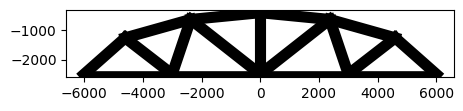

In [21]:
m = truss_model(dvs)
plots.setup(m)
plots.plot_members(m, min_linewidth=1, max_linewidth=8)
plots.show(m) 

## Conclusions

The optimization results in an arch, which efficiently uses the material of the bars. It is possible for this optimization problem to have no solution: We just have to ask for something that the structure is incapable of doing, such as a much smaller maximum deflection (try just 1 mm!).